In [1]:
# 训练流程：
# 1.准备数据集以及一些预处理操作
# 2.准备模型
# 3.设置优化器以及损失函数
# 4.具体的循环训练
# 5.验证模型效果并且保存最好的那次模型
# 6.测试一下模型的效果

In [45]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms,models
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
from tqdm.auto import tqdm
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [3]:

# 判断当前电脑是否有gpu,如果有就是有gpu加速训练，没有的话，只能使用cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda')

# 最重要的知识点 -自定义 Dataset类

In [7]:
class PathologyDataset(Dataset):
    def __init__(self,image_paths,labels,tranform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.tranform = tranform
    def __getitem__(self,index):
        image = Image.open(self.image_paths[index]).convert('RGB')
        if self.tranform:
            image = self.tranform(image)
        label = self.labels[index]
        
        return image,label
        
    def __len__(self):
        return len(self.image_paths)

In [8]:
# 类别映射
# 

class_to_idx = {'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}

In [13]:
## 收集数据
image_paths = []
labels = []
data_root = os.path.join('.','patho')
data_root

'.\\patho'

In [19]:
# 遍历所有类别文件夹收集数据
for class_name in class_to_idx.keys():
#     print(class_name)
    class_path = os.path.join(data_root,class_name)
#     print(class_path)
    if os.path.exists(class_path):
        files = os.listdir(class_path)
#         print("files = ",files[:5])
        print(f"在{class_name}文件夹中找到了{len(files)}个文件")
        for img_name in files:
            image_paths.append(os.path.join(class_path,img_name))
            labels.append(class_to_idx[class_name])


在colon_aca文件夹中找到了5000个文件
在colon_n文件夹中找到了5000个文件
在lung_aca文件夹中找到了5000个文件
在lung_n文件夹中找到了5000个文件
在lung_scc文件夹中找到了5000个文件


In [20]:
image_paths[:5]

['.\\patho\\colon_aca\\colonca1.jpeg',
 '.\\patho\\colon_aca\\colonca10.jpeg',
 '.\\patho\\colon_aca\\colonca100.jpeg',
 '.\\patho\\colon_aca\\colonca1000.jpeg',
 '.\\patho\\colon_aca\\colonca1001.jpeg']

In [21]:
labels[:5]

[0, 0, 0, 0, 0]

In [22]:
len(image_paths)

25000

In [23]:
len(labels)

25000

In [27]:
len(image_paths)

25000

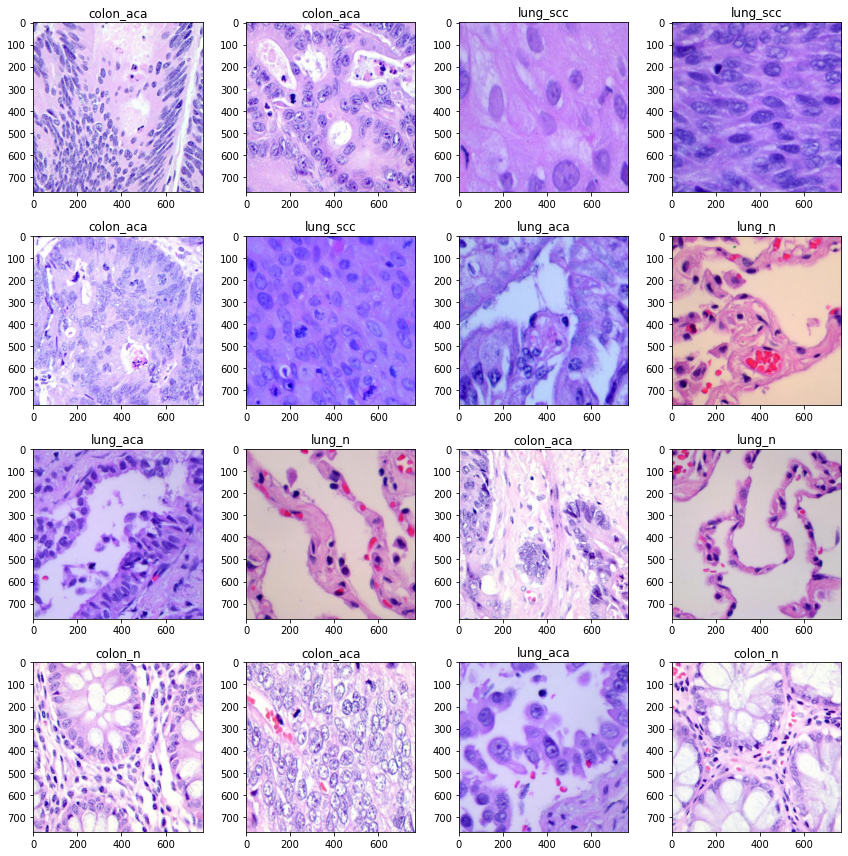

In [40]:
## 可视化图片和标签
plt.figure(figsize=(12,12))
# 随机取16张图像
random_indices = np.random.choice(len(image_paths),16)
random_indices
for i,idx in enumerate(random_indices):
#     print(idx)
    img = Image.open(image_paths[idx]).convert('RGB')
    label = labels[idx]
#     print("label = ",label)
    class_name = [k for k,v in class_to_idx.items() if v == label][0]
#     print(class_name)
    
    # 开始绘制子图
    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(class_name)
plt.tight_layout()
plt.show()

In [41]:
len(random_indices)

16

In [42]:
class_to_idx

{'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}

In [43]:
# 1.准备数据集以及一些预处理操作

In [44]:
# 数据预处理

# 训练集的预处理
transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

# 验证集的预处理
val_transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
])


In [47]:
## 自己手动划分训练集和测试集
# 8:2

# train_test_split(
#     *arrays,
#     test_size=None,
#     train_size=None,
#     random_state=None,
#     shuffle=True,
#     stratify=None,
# )

train_paths,val_paths,train_labels,val_labels = train_test_split(image_paths,labels,test_size=0.2,random_state=42,stratify=labels)

In [48]:
len(train_paths),len(train_labels)

(20000, 20000)

In [49]:
len(val_paths),len(val_labels)

(5000, 5000)

In [50]:
train_paths[:5]

['.\\patho\\colon_n\\colonn2344.jpeg',
 '.\\patho\\lung_n\\lungn2635.jpeg',
 '.\\patho\\lung_n\\lungn1008.jpeg',
 '.\\patho\\lung_n\\lungn4766.jpeg',
 '.\\patho\\colon_n\\colonn1245.jpeg']

In [51]:
train_labels[:5]

[1, 3, 3, 3, 1]

In [62]:
## 创建数据集和dataloader
train_dataset = PathologyDataset(image_paths,labels,transform)
val_dataset = PathologyDataset(val_paths,val_labels,val_transform)

train_loader = DataLoader(train_dataset,16,shuffle=True)
val_loader = DataLoader(val_dataset,16,shuffle=False)

In [63]:
class_to_idx

{'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}

In [64]:
len(class_to_idx)

5

In [65]:
# 我们还是使用resnet50,并且改成我们自己的5个分类
model = models.resnet50()
num_classes = len(class_to_idx)

model.fc = nn.Linear(model.fc.in_features,num_classes)

model = model.to(device)

In [66]:
# 损失函数
criterion = nn.CrossEntropyLoss()
# optim.Adam(
#     params,
#     lr=0.001,
#     betas=(0.9, 0.999),
#     eps=1e-08,
#     weight_decay=0,
#     amsgrad=False,
# )
# 优化器
optimizer = optim.Adam(model.parameters(),lr=0.001)

# 学习率下降策略
# optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size,
#     gamma=0.1,
#     last_epoch=-1,
#     verbose=False,
# )
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=1,gamma=0.1)


In [67]:
# 真正开始训练
num_epoches = 2
best_val_acc = 0.0

print("真正开始训练....")

for epoch in range(num_epoches):
    print("当前epoch = ",(epoch + 1))
    
    # 训练阶段
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    # 添加进度条
    train_pbar = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{num_epoches}")
    for images,labels in train_pbar:
        # 我们需要使用gpu加速训练
        images,labels = images.to(device),labels.to(device)
        
        # 模型前向过程
        outputs = model(images)
        
        # 求损失
#         loss(input, target)
        loss = criterion(outputs,labels)
        
        
         # 梯度清零
        optimizer.zero_grad()
        # 反向传播
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        # 得到所属类别
#         print("outputs = ",outputs)
#         print("outputs.shape = ",outputs.shape)
        predicted = torch.argmax(outputs,dim=1)
#         print("predicted = ",predicted)
        
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        train_pbar.set_postfix({
            'loss': f'{train_loss/train_total: .4f}',
            'acc': f'{100*train_correct / train_total : 2f}%'
        })
    
    # 整个训练batch的损失和精度
    train_loss = train_loss / len(train_loader)
    train_acc = 100*train_correct / train_total
    
    
    # 验证一下模型的效果
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    
    # 验证集也添加进度条
    val_pbar = tqdm(val_loader,desc=f'Validating Epoch {epoch + 1}/{num_epoches}')
    # 96
    # batch_size = 10
    with torch.no_grad():
        for images,labels in val_pbar:
            
            images,labels = images.to(device),labels.to(device)
            
            # 进行模型前向传播
            outputs = model(images)
            
            # 求loss
            loss = criterion(outputs,labels)
            val_loss += loss.item()
            
            predicted = torch.argmax(outputs,dim=1)
            
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
            # 更新进度条
            val_pbar.set_postfix({
                'val loss': f'{val_loss/val_total: .4f}',
                'val acc': f'{100*val_correct/val_total : .2f}%'
            })
        
        # 整个验证集的平均损失和精度
        val_loss = val_loss / len(val_loader)
        val_acc = 100*val_correct / val_total
        
        
        # 更新一下我们的学习率
        scheduler.step()
    
    
        # 我们其实会保存在验证集上效果最好的模型参数
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # 保存模型参数
            
#             torch.save(
#                 obj,
#                 f: Union[str, os.PathLike, BinaryIO, IO[bytes]],
#                 pickle_module=<module 'pickle' from 'D:\\ProgramData\\Anaconda3\\envs\\py38\\lib\\pickle.py'>,
#                 pickle_protocol=2,
#                 _use_new_zipfile_serialization=True,
#             ) -> None
            
            torch.save(model.state_dict(),"best_model.pth")
            print("保存新的最近模型 val_acc = ",val_acc)
        
        print(f"Epoch [{epoch + 1}/{num_epoches}]")
        print(f"Train Loss: {train_loss: 4f}, Train Acc: {train_acc: 2f}%")
        print(f"Val Loss: {val_loss: 4f}, Val Acc: {val_acc: 2f}%")
        print("===============================")

真正开始训练....
当前epoch =  1


Training Epoch 1/2:   0%|          | 0/1563 [00:00<?, ?it/s]

Validating Epoch 1/2:   0%|          | 0/313 [00:00<?, ?it/s]

保存新的最近模型 val_acc =  55.3
Epoch [1/2]
Train Loss:  0.410559, Train Acc:  84.752000%
Val Loss:  2.209044, Val Acc:  55.300000%
当前epoch =  2


Training Epoch 2/2:   0%|          | 0/1563 [00:00<?, ?it/s]

Validating Epoch 2/2:   0%|          | 0/313 [00:00<?, ?it/s]

保存新的最近模型 val_acc =  97.16
Epoch [2/2]
Train Loss:  0.117125, Train Acc:  95.532000%
Val Loss:  0.072445, Val Acc:  97.160000%


In [68]:
## 需要加载最好验证集的模型参数
print("开始测试最佳模型...")

state_dict = torch.load("best_model.pth")
model.load_state_dict(state_dict)

# 验证模式
model.eval()




开始测试最佳模型...


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [69]:
# 准备测试数据
# 验证集的预处理
test_transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
])

In [70]:
class_to_idx

{'colon_aca': 0, 'colon_n': 1, 'lung_aca': 2, 'lung_n': 3, 'lung_scc': 4}

In [73]:
idx_to_class = {v: k for k,v in class_to_idx.items()}
idx_to_class

{0: 'colon_aca', 1: 'colon_n', 2: 'lung_aca', 3: 'lung_n', 4: 'lung_scc'}

In [76]:
# 先创建一个空的混淆矩阵
confusion_matrix = np.zeros((num_classes,num_classes),dtype=int)
confusion_matrix

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]])

In [80]:
a = [1,2,3]
b = ['a','b','c']

for a_,b_ in zip(a,b):
    print(a_, " ",b_)

1   a
2   b
3   c


测试:   0%|          | 0/313 [00:00<?, ?it/s]

AttributeError: 'dict' object has no attribute 'key'

D:\ProgramData\Anaconda3\envs\py38\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ProgramData\Anaconda3\envs\py38\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ProgramData\Anaconda3\envs\py38\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ProgramData\Anaconda3\envs\py38\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


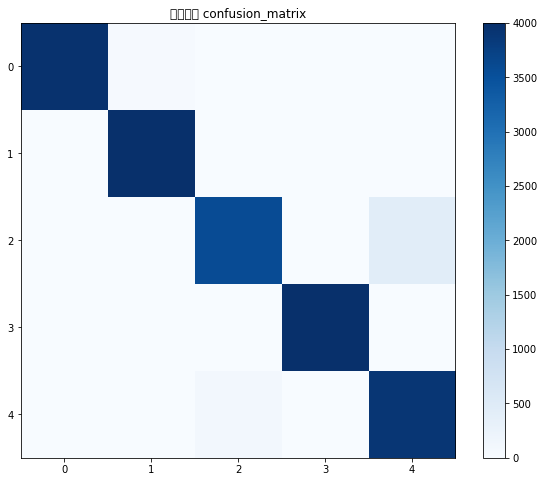

In [83]:
# 开始测试
with torch.no_grad():
    test_pbar = tqdm(val_loader,desc="测试")
    for images,labels in (test_pbar):
        images,labels = images.to(device),labels.to(device)
        
        # 模型推理
        outputs = model(images)
        predicted = torch.argmax(outputs,dim=1)
        
        # 更新混淆矩阵
        for true,pred in zip(labels.cpu().numpy(),predicted.cpu().numpy()):
            confusion_matrix[true][pred] += 1
        
        # 更新进度条的描述
        test_pbar.set_postfix({
            'acc' : f'{100 * predicted.eq(labels).sum().item()/labels.size(0) : .2f}%'
        })
        
# 可视化一下混淆矩阵
plt.figure(figsize=(10,8))
plt.imshow(confusion_matrix,interpolation='nearest',cmap=plt.cm.Blues)
plt.title('混淆矩阵 confusion_matrix')
plt.colorbar()

classes = list(class_to_idx.keys())
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks,classes,rotation=45)
plt.yticks(tick_marks,classes)
# 在混淆矩阵中每个格子添加数值




In [87]:
confusion_matrix

array([[6944,   56,    0,    0,    0],
       [   0, 7000,    0,    0,    0],
       [   0,    0, 6237,   14,  749],
       [   0,    0,    7, 6993,    0],
       [   0,    0,  168,    0, 6832]])

测试:   0%|          | 0/313 [00:00<?, ?it/s]

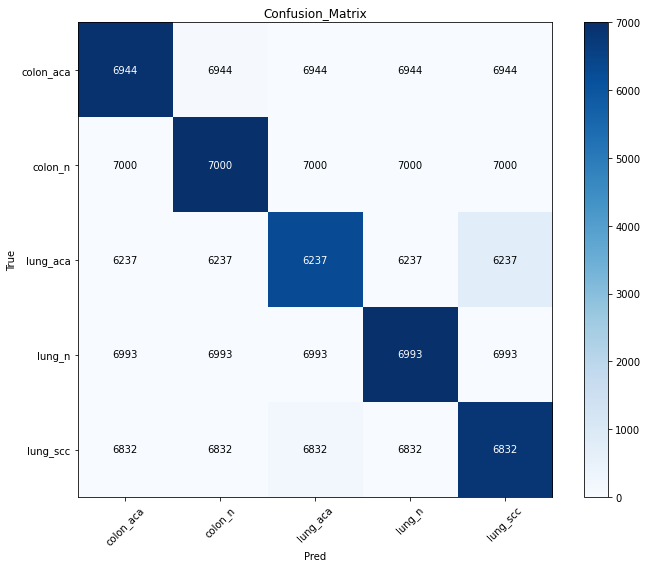

In [86]:
# 开始测试
with torch.no_grad():
    test_pbar = tqdm(val_loader,desc="测试")
    for images,labels in (test_pbar):
        images,labels = images.to(device),labels.to(device)
        
        # 模型推理
        outputs = model(images)
        predicted = torch.argmax(outputs,dim=1)
        
        # 更新混淆矩阵
        for true,pred in zip(labels.cpu().numpy(),predicted.cpu().numpy()):
            confusion_matrix[true][pred] += 1
        
        # 更新进度条的描述
        test_pbar.set_postfix({
            'acc' : f'{100 * predicted.eq(labels).sum().item()/labels.size(0) : .2f}%'
        })
        
# 可视化一下混淆矩阵
plt.figure(figsize=(10,8))
plt.imshow(confusion_matrix,interpolation='nearest',cmap=plt.cm.Blues)
plt.title('Confusion_Matrix')
plt.colorbar()

classes = list(class_to_idx.keys())
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks,classes,rotation=45)
plt.yticks(tick_marks,classes)
# 在混淆矩阵中每个格子添加数值
thresh = confusion_matrix.max()/2 # 设置阈值主要是为了显示方便
# 可以将数值分为两部分，较大值（颜色较深的格子），较小值（颜色较浅）
for i in range(len(classes)):
    for j in range(len(classes)):
        # 在混淆矩阵的每个格子中添加数值，根据数值大小调整字体颜色
        plt.text(j,i,format(confusion_matrix[i,i],'d'),ha='center',va='center',color="white" if confusion_matrix[i,j] > thresh else "black")

plt.xlabel('Pred') # 设置x轴标签
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=300) # 保存图像
plt.show()



